# Other featuring engineering techniques
## Clustering data instances
Unsupervised ML algorithms are specially valuable for adding extra information to our models, because those algorithms don't care about target variable. Unsupervised methods can uncover hidden structures in data and relationships that a predictor can't learn as they are too complex. The strategy consists on creating a new variable that can be used as input for our models, its value is the cluster label assigned by clustering algorithm. Performs specially well on spatial data (like coordinates) but aren't limited for a specific context.

In [1]:
from sklearn.model_selection import train_test_split
from pandas import read_csv
import matplotlib.pyplot as plt

DATA = read_csv("/kaggle/input/datasets/debayank2024/house-price-prediction/modified_data.csv")
NUMS = ["sqft_living", "bathrooms", "bedrooms", "sqft_lot", "floors", "sqft_above", "sqft_basement", "yr_built", "price_per_sqft"]
CATS = ["waterfront", "view", "condition"]
TARGET = "price"

data = DATA.drop(columns=["street"])

x_train, x_test, y_train, y_test = train_test_split(data[NUMS + CATS + ["city", "statezip"]], data[TARGET], test_size=0.2, random_state=123)


In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

TRANSFORMER = ColumnTransformer([
    ("standarized", StandardScaler(), NUMS),
    ("encoding", OrdinalEncoder(), ["city", "statezip"])
], verbose_feature_names_out=False, remainder="passthrough")

TRANSFORMER.set_output(transform="pandas")

X_train = TRANSFORMER.fit_transform(x_train)
X_test = TRANSFORMER.transform(x_test)

KMEANS = KMeans(n_clusters=3, random_state=123)
KMEANS.fit(X_train)

X_train_kmeans = X_train.copy()
X_train_kmeans["cluster"] = KMEANS.predict(X_train_kmeans)

X_test_kmeans = X_test.copy()
X_test_kmeans["cluster"] = KMEANS.predict(X_test_kmeans)

SIMPLE_MODEL = GradientBoostingRegressor(random_state=123, learning_rate=0.05, n_estimators=200)
SIMPLE_MODEL.fit(X_train, y_train)

SIMPLE_PREDS = SIMPLE_MODEL.predict(X_test)
SIMPLE_SQUARED_ERROR = mean_squared_error(y_test, SIMPLE_PREDS)

KMEANS_MODEL = GradientBoostingRegressor(random_state=123, learning_rate=0.05, n_estimators=200)
KMEANS_MODEL.fit(X_train_kmeans, y_train)

KMEANS_PREDS = KMEANS_MODEL.predict(X_test_kmeans)
KMEANS_SQUARED_ERROR = mean_squared_error(y_test, KMEANS_PREDS)

print("Squared error on simple dataset: ", SIMPLE_SQUARED_ERROR)
print("Squared error with K-Means: ", KMEANS_SQUARED_ERROR)

Squared error on simple dataset:  8591381702.944876
Squared error with K-Means:  7834039969.895309


<Axes: xlabel='city', ylabel='statezip'>

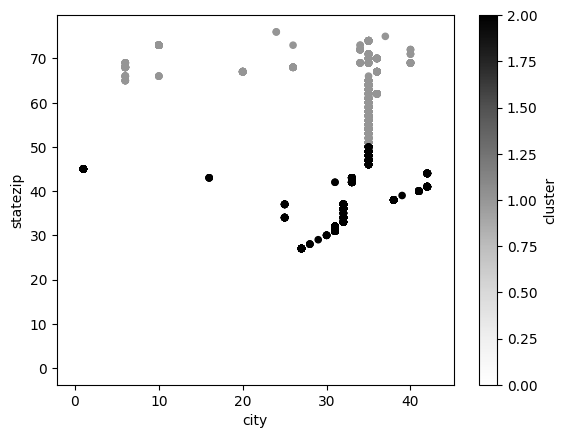

In [3]:
X_train_kmeans.plot.scatter(x="city", y="statezip", c="cluster")

## Creating new features
Unlike other methods that consists on using statistical tests, this time we are going to discuss about creating new features from our currently features. To develop more features is necessary some domain knowledge about the problem and of course a depth understanding of your features. The approach consists on adding some measures like mean, value counts or even creating a custom measure not available in the dataset but can be calculated from our data. This is like lifting models work because we are adding measures that represents complex relationships difficult to learn to our model. A good strategy to find insights is visualizing our variables in a regular or logarithm scale. Another possible measure is adding a column representing the sum of related columns (often used on binary variables).  
Other methods are splitting strings into significant tokens that contributes some information to the model like country or state codes, this is specially useful on geospatial data and datetimes. Grouping data on some categories is also useful to perform calculations and include those to the dataset. Finally, I would like to share some advices:
- Linear models learns sums and differences naturally, but can't learn anything more complex.
- Ratios seem to be difficult for most models to learn.
- Tree models can learn to approximate almost any combination of features, but when a combination is especially important they can still benefit from having it explicitly created, especially when data is limited.
- Counts are especially helpful for tree models, since these models don't have a natural way of aggregating information across many features at once.

## Principal component analysis (PCA)
PCA is a dimensionality reduction technique that help us to reduce the number of features in a dataset while keeping the most important information. Transforms correlated features into a smaller set of uncorrelated components. Bases on the concept of "principal components" that consists in calculating eigenvalues (importances) and eigenvectors (directions) from covariance matrix. Then we must select top $k$ components that capture most of the variance. Firsts components holds the direction of maximum variance while lower.

### How to use it on feature engineering?
Use the components themselves as features, because they are more informative than the original features.

**Considerations:**
- Removes components with low variance.
- Reduces data with fewer components lowering computational costs.
- Every variable **must be standarized**.
- Only works with quantitative features.
- Sensitivity to outliners (consider removing them).
- Information loss as result as a reduced set of components are hold.
- New components are combinations of original variables, so can be difficult to explain.

In [4]:
from sklearn.decomposition import PCA

# A PCA holding 90% of the variance
REDUCER = PCA(n_components=0.9,random_state=123)

NUM_PIPELINE = Pipeline(steps=[
    ("standarized", StandardScaler()),
    ("pca", REDUCER)
])

PCA_TRANSFORMER = ColumnTransformer([
    ("standarized", NUM_PIPELINE, NUMS),
    ("encoding", OrdinalEncoder(), ["city", "statezip"])
], verbose_feature_names_out=False, remainder="passthrough")

PCA_TRANSFORMER.set_output(transform="pandas")

X_train_pca = PCA_TRANSFORMER.fit_transform(x_train)
X_test_pca = PCA_TRANSFORMER.transform(x_test)

SIMPLE_MODEL = GradientBoostingRegressor(random_state=123, learning_rate=0.05, n_estimators=200)
SIMPLE_MODEL.fit(X_train, y_train)

SIMPLE_PREDS = SIMPLE_MODEL.predict(X_test)
SIMPLE_SQUARED_ERROR = mean_squared_error(y_test, SIMPLE_PREDS)

PCA_MODEL = GradientBoostingRegressor(random_state=123, learning_rate=0.05, n_estimators=200)
PCA_MODEL.fit(X_train_pca, y_train)

PCA_PREDS = PCA_MODEL.predict(X_test_pca)
PCA_SQUARED_ERROR = mean_squared_error(y_test, KMEANS_PREDS)

print("Squared error on simple dataset: ", SIMPLE_SQUARED_ERROR)
print("Squared error on PCA model: ", PCA_SQUARED_ERROR)

Squared error on simple dataset:  8591381702.944876
Squared error on PCA model:  7834039969.895309


## Embedded methods

Performs feature selection on model training proccess, works for some models that assigns importance to each feature. Some available algorithms are: **Lasso (L1 regularization)**, **Ridge (L2 regularization)**, **ElasticNet**, **Tree based models**, **regularized logistic regression** or **SVM with L1 penalty**.

**Considerations:**
- Help avoid overfitting by removing useless features.
- Only works with certain algorithms.
- Hard to interpret for ensemble or gradient based models.

In [5]:
from sklearn.feature_selection import SelectFromModel

SELECTOR = SelectFromModel(
    estimator=GradientBoostingRegressor(
        random_state=123, learning_rate=0.05, n_estimators=200
    )
).fit(X_train, y_train)
SELECTOR.set_output(transform="pandas")

EMBEDDED_MODEL = GradientBoostingRegressor(random_state=123, learning_rate=0.05, n_estimators=200)
EMBEDDED_MODEL.fit(SELECTOR.transform(X_train), y_train)

EMBEDDED_PREDS = EMBEDDED_MODEL.predict(SELECTOR.transform(X_test))
EMBEDDED_ERROR = mean_squared_error(y_test, EMBEDDED_PREDS)

print("Squared error on embedded model: ", EMBEDDED_ERROR)
print("Selected features from Gradient tree: ", SELECTOR.get_feature_names_out())

Squared error on embedded model:  6012194764.672276
Selected features from Gradient tree:  ['sqft_living' 'price_per_sqft']
